In [1]:
!poetry install -q

In [2]:
%load_ext autoreload
%autoreload 2

import os
import sys
import datetime
import numpy as np
import pandas as pd
from dotenv import load_dotenv

# OpenMP 다중 로드 허용 및 스레드 경쟁 방지 환경 변수 (최상단 주입 필수)
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

# 1. 프로젝트 경로 설정 및 환경 변수 명시적 로드
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

# Docker 네트워크 외부(Host OS)에서 실행되는 Jupyter를 위한 DNS 해석 우회 처리
local_s3_endpoint = os.environ.get("LOCAL_S3_ENDPOINT", "")
if "localstack" in local_s3_endpoint:
    os.environ["LOCAL_S3_ENDPOINT"] = local_s3_endpoint.replace("localstack", "localhost")

In [3]:
# DataFrame 출력 생략 방지 옵션 설정
pd.set_option('display.max_columns', None)        # 숨김 없이 모든 컬럼 출력
pd.set_option('display.max_colwidth', None)       # 컬럼 안의 긴 텍스트(Dict/List) 전체 출력
pd.set_option('display.expand_frame_repr', False) # 가로 너비 초과 시 줄바꿈 방지
pd.set_option('display.max_rows', 50)             # 필요시 최대 출력 행 수 조정

In [ ]:
# ==============================================================================
# [셀 0] 주피터 분석 환경 전용 MinIO 및 MLflow 환경 변수 세팅
# ==============================================================================
import os
import warnings
import logging
from dotenv import find_dotenv, load_dotenv
from mlflow.tracking import MlflowClient
from tqdm import TqdmWarning
from pandas.errors import PerformanceWarning
from src.model.tracker.mlflow_tracker import MLflowTracker

# 1. 루트 디렉터리의 .env 파일 자동 탐색 및 로드
load_dotenv(find_dotenv())

# 2. MinIO S3 및 AWS 자격 증명 환경 변수 세팅
os.environ["AWS_ACCESS_KEY_ID"] = os.getenv("AWS_ACCESS_KEY_ID")
os.environ["AWS_SECRET_ACCESS_KEY"] = os.getenv("AWS_SECRET_ACCESS_KEY")
os.environ["AWS_DEFAULT_REGION"] = os.getenv("AWS_DEFAULT_REGION")
os.environ["LOCAL_S3_ENDPOINT"] = os.getenv("MLFLOW_S3_ENDPOINT_URL")

# 3. MLflow Tracking & S3 아티팩트 스토어 연동 설정
MLFLOW_TRACKING_URI = os.getenv("MLFLOW_TRACKING_URI")
os.environ["MLFLOW_TRACKING_URI"] = MLFLOW_TRACKING_URI
os.environ["MLFLOW_S3_ENDPOINT_URL"] = os.getenv("MLFLOW_S3_ENDPOINT_URL")
os.environ["MLFLOW_S3_IGNORE_TLS"] = "true"
# MLflow 공식 표준 출력 URL 링크 차단 환경변수 (소프트웨어 공식 플래그)
os.environ["MLFLOW_SUPPRESS_PRINTING_URL_TO_STDOUT"] = "true"

# 4. 경고 필터링
warnings.filterwarnings("ignore", category=TqdmWarning)
warnings.filterwarnings("ignore", category=PerformanceWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=SyntaxWarning)

# MLFlow 활성화
EXPERIMENT_NAME: str = "Single_Model_FineTuning"
tracker = MLflowTracker(experiment_name=EXPERIMENT_NAME)

/Users/junsu/code/Project/AssetMind/apps/data-pipeline/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🎯 [MLflow Tracker Active] Experiment: 'Single_Model_FineTuning' (ID: 1)


In [5]:
# ==============================================================================
# [셀 1] 완성형 챔피언 데이터셋(80:20) 로드 및 Walk-Forward CV 시계열 분할 무결성 감사
# ==============================================================================
import pandas as pd
from src.model.dataset.loader import ChampionDatasetLoader
from src.model.dataset.walk_forward_splitter import WalkForwardSplitter

# ------------------------------------------------------------------------------
# Step 1. get_best_dataset.ipynb에서 확정된 champion_dataset.pkl 로드 및 검증
# ------------------------------------------------------------------------------
X_train, y_train, X_test, y_test, X_inference = ChampionDatasetLoader.load_champion_dataset("champion_dataset.pkl")

# ------------------------------------------------------------------------------
# Step 2. 상위 80:20 Hold-out 파티션 통계 및 무결성 감사 대시보드 사출
# ------------------------------------------------------------------------------
partition_summary_df = ChampionDatasetLoader.create_partition_summary(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    X_inference=X_inference
)
display(partition_summary_df)

# ------------------------------------------------------------------------------
# Step 3. Train(80%) 내부 동적 Walk-Forward CV 분할 구간 정밀 감사표 사출
# ------------------------------------------------------------------------------
walk_forward_splitter = WalkForwardSplitter(n_splits=5, forecast_horizon=20, min_train_ratio=0.5)
walk_forward_audit_df = walk_forward_splitter.summarize(X=X_train, y=y_train)

print("\n" + "=" * 122)
print(f"[Expanding-Window Walk-Forward CV Audit Dashboard] Total Folds: {len(walk_forward_audit_df)} Folds (Dynamic Sized)")
print("=" * 122)
display(walk_forward_audit_df)

 🚀 [Champion Dataset Ingestion] 'champion_dataset.pkl' 로드 완료 (2.95 ms | 크기: 893.88 KB)
 📌 Model-Ready Feature Dimension: 12개 정예 피처 선별 완비


,"X Shape (행, 피처)",y Shape (타겟),시계열 시작일,시계열 종료일,타겟 평균 (Mean),타겟 표준편차 (Std),타겟 범위 (Min ~ Max)
파티션 (Partition),,,,,,,
Train Set (개발/CV 튜닝용 80%),"(3068, 12)","(3068,)",2016-01-01,2024-06-03,0.0019,0.5440,"[-1.2584, 1.5334]"
Test Set (최종 실전평가용 20%),"(767, 12)","(767,)",2024-06-24,2026-08-01,0.0196,0.4195,"[-1.0338, 1.1107]"
Inference Set (실시간 추론 전용 T+20),"(20, 12)",N/A (미래 정답 미도래),2026-08-02,2026-08-21,-,-,-



[Expanding-Window Walk-Forward CV Audit Dashboard] Total Folds: 5 Folds (Dynamic Sized)


,Train 기간 (Expanding),Train 규격,Purged Gap (20d),Gap 규격,Validation 기간,Val 규격,검증 비고
Fold,,,,,,,
Fold 1,2016-01-01 ~ 2020-03-02,"1,518 Rows",2020-03-03 ~ 2020-03-22,20 Rows,2020-03-23 ~ 2021-01-23,306 Rows,Train 49.5% ➔ Val 10.0%
Fold 2,2016-01-01 ~ 2021-01-03,"1,824 Rows",2021-01-04 ~ 2021-01-23,20 Rows,2021-01-24 ~ 2021-11-25,306 Rows,Train 59.5% ➔ Val 10.0%
Fold 3,2016-01-01 ~ 2021-11-05,"2,130 Rows",2021-11-06 ~ 2021-11-25,20 Rows,2021-11-26 ~ 2022-09-28,306 Rows,Train 69.4% ➔ Val 10.0%
Fold 4,2016-01-01 ~ 2022-09-08,"2,436 Rows",2022-09-09 ~ 2022-09-28,20 Rows,2022-09-29 ~ 2023-08-01,306 Rows,Train 79.4% ➔ Val 10.0%
Fold 5,2016-01-01 ~ 2023-07-12,"2,742 Rows",2023-07-13 ~ 2023-08-01,20 Rows,2023-08-02 ~ 2024-06-03,306 Rows,Train 89.4% ➔ Val 10.0%


 [Stage 2 TimeSeries Walk-Forward HPO Launch] Target Models: 3 | Early Stopping (Patience: 20)
  [ElasticNet] Walk-Forward CV HPO Running ... Done (1.49s | Trials: 25 | Score: 0.8685)
     [XGBoost] Walk-Forward CV HPO Running ... Done (13.41s | Trials: 33 | Score: 0.8832)
[RandomForest] Walk-Forward CV HPO Running ... Done (25.21s | Trials: 23 | Score: 0.8848)

[Stage 2 Time-Series Walk-Forward HPO Optimization Summary Dashboard]


,탐색 횟수 (Trials),CV 평균 MDA,CV 평균 Rank IC,CV 평균 ICIR,CV 평균 Sharpe,CV 평균 Sortino,CV 평균 MDD,CV 평균 t-stat,CV 평균 RMSE,CV 평균 MAE,복합 점수 (Composite),최적 파라미터 (Best Parameters),소요 시간 (Search Time)
알고리즘 (Algorithm),,,,,,,,,,,,,
ElasticNet,25 회,63.59%,0.6982,4.78,2.17,20.79,3.12%,14.66,0.325754,0.228630,0.8685,"alpha=0.0668, l1_ratio=0.7039",1.49s
XGBoost,33 회,69.15%,0.7114,4.62,2.30,28.76,2.94%,15.51,0.291584,0.202525,0.8832,"objective=reg:absoluteerror, n_estimators=390, max_depth=3, learning_rate=0.0138, min_child_weight=3, gamma=0.3281, subsample=0.7170, colsample_bytree=0.9369, reg_alpha=0.2931, reg_lambda=0.0054",13.41s
RandomForest,23 회,69.61%,0.7224,4.48,2.31,32.79,2.87%,15.56,0.293266,0.201363,0.8848,"criterion=friedman_mse, n_estimators=175, max_depth=6, min_samples_split=18, min_samples_leaf=3, max_features=0.6895",25.21s



[Stage 2 HPO Convergence History & Parameter Importance Visualization]


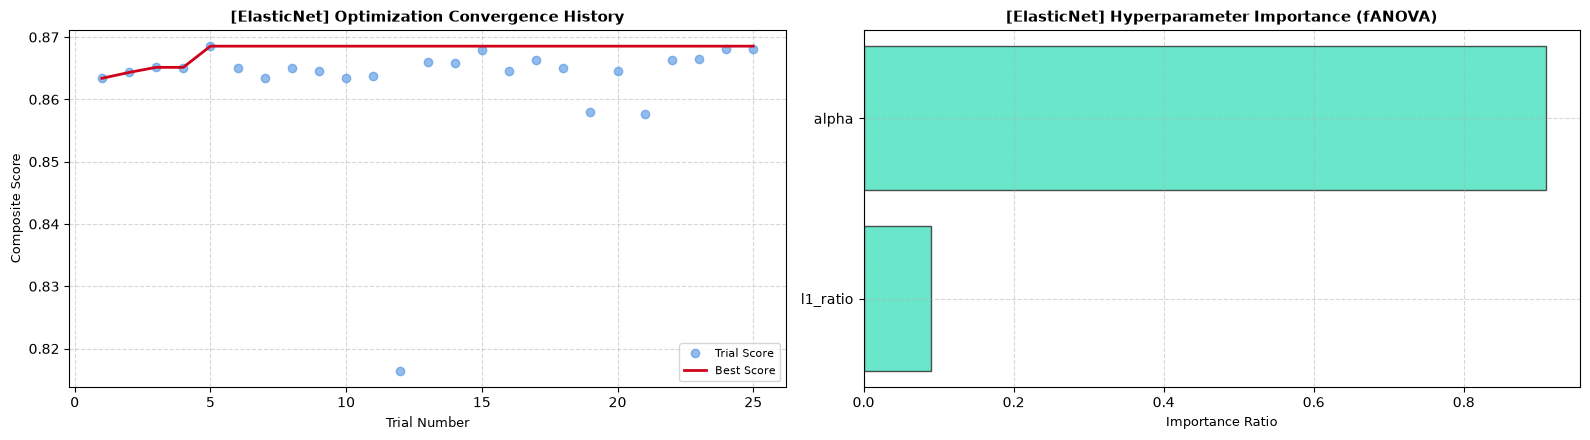

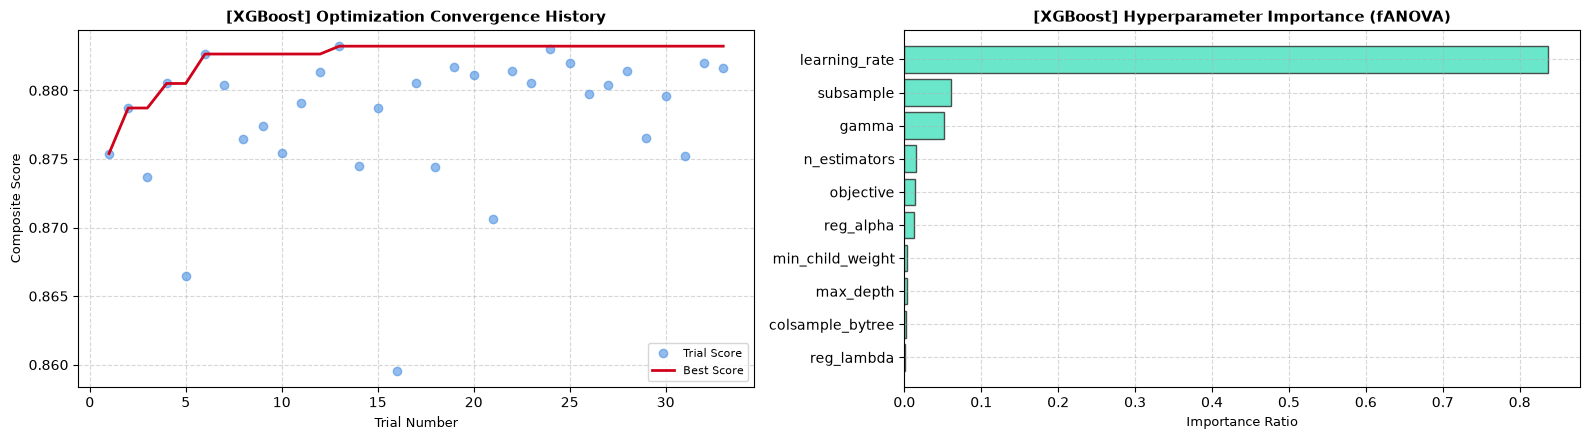

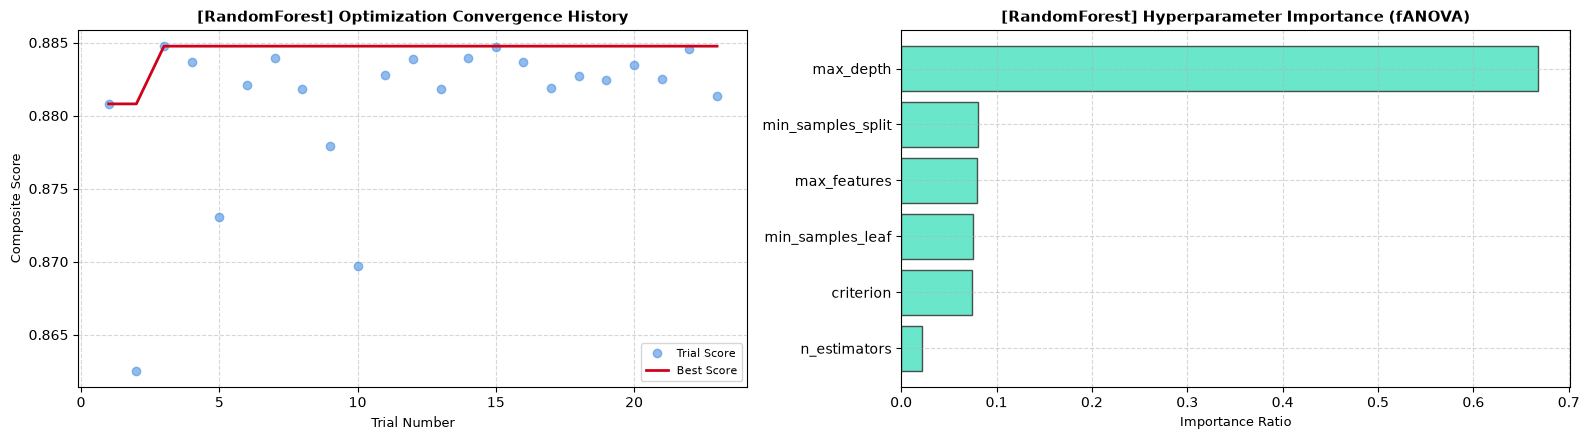

In [6]:
# ==============================================================================
# [셀 2] 3대 단일 회귀 모델군 대상 Walk-Forward CV 자율 HPO 최적화 (SingleModelOptimizer)
# ==============================================================================
import matplotlib.pyplot as plt
from src.model.optimization.search_space import get_search_spaces, audit_search_space_boundaries
from src.model.optimization.single_model_optimizer import SingleModelOptimizer
from src.model.visualization.optimizer_visualizer import OptimizerVisualizer

# ------------------------------------------------------------------------------
# Step 1. 표준 탐색 공간 로드 (필요 시 특정 파라미터 범위 Override 가능)
# ------------------------------------------------------------------------------
search_spaces = get_search_spaces()
search_spaces["XGBoost"]["n_estimators"]["high"] = 400
search_spaces["RandomForest"]["max_depth"]["high"] = 10

# ------------------------------------------------------------------------------
# Step 2. 3대 단일 모델 순차 HPO 실행 및 80% Full Refit
# [설계 의도] Step 5에서 시각화 아티팩트와 함께 단일 MLflow Run으로 통합 로깅하기 위해 tracker=None 전달
# ------------------------------------------------------------------------------
single_model_optimizer = SingleModelOptimizer(
    splitter=walk_forward_splitter,
    tracker=None,
    patience=20,
    max_trials=80
)
optimization_registry = single_model_optimizer.optimize_all(
    X_train=X_train,
    y_train=y_train,
    search_spaces=search_spaces
)

# ------------------------------------------------------------------------------
# Step 3. Optuna HPO 정산 대시보드 사출
# ------------------------------------------------------------------------------
print("\n" + "=" * 122)
print("[Stage 2 Time-Series Walk-Forward HPO Optimization Summary Dashboard]")
print("=" * 122)
display(optimization_registry.summary_dataframe)

# ------------------------------------------------------------------------------
# Step 4. Search Space 경계 도달 파라미터 단일 통합 감사표 사출 (조건부)
# ------------------------------------------------------------------------------
boundary_audit_dataframe = audit_search_space_boundaries(optimization_registry.hpo_results)
if not boundary_audit_dataframe.empty:
    print("\n" + "-" * 122)
    print("[Search Space Boundary Adjustment Required Table]")
    print("-" * 122)
    display(boundary_audit_dataframe)

# ------------------------------------------------------------------------------
# Step 5. HPO 최적화 수렴 궤적 및 파라미터 중요도 시각화 사출 및 MLflow 로깅
# ------------------------------------------------------------------------------
print("\n" + "=" * 122)
print("[Stage 2 HPO Convergence History & Parameter Importance Visualization]")
print("=" * 122)

for model_name, result_dto in optimization_registry.hpo_results.items():
    convergence_figure = OptimizerVisualizer.plot_convergence(
        study=result_dto.study,
        model_name=model_name
    )
    # [설계 의도] 수치 지표, 파라미터, 시각화 플롯 아티팩트를 단일 Active Run으로 원자적 영속화
    tracker.log_hpo_result(
        model_name=model_name,
        result_dto=result_dto,
        fig=convergence_figure
    )
    plt.show()

In [7]:
# ==============================================================================
# [셀 3] 6대 평가 계층 기반 Holdout Test 종합 평가 및 1위 Champion 확정
# ==============================================================================
from src.model.evaluation.single_model_evaluator import SingleModelEvaluator

# ------------------------------------------------------------------------------
# Step 1. 3대 모델 Holdout Test 10대 다차원 지표 평가 집행 (기본 게이트/가중치 자동 적용)
# ------------------------------------------------------------------------------
evaluator = SingleModelEvaluator(tracker=tracker)
comparison_df = evaluator.evaluate(
    optimization_registry=optimization_registry,
    X_test=X_test,
    y_test=y_test
)

# ------------------------------------------------------------------------------
# Step 2. 2단계 게이트 통과 & 가중 복합 스코어 1위 Champion 모델 발탁
# ------------------------------------------------------------------------------
champion = evaluator.get_best_model(criterion="composite")

# 후속 셀([셀 4] XAI, [셀 5] 배포 명세서) 연동을 위한 Champion DTO 변수 바인딩
champion_model_name = champion.name
champion_model = champion.model
champion_best_hyperparameters = champion.best_hyperparameters
champion_composite_score = champion.composite_score
champion_test_mda = champion.test_mda
champion_test_rmse = champion.test_rmse
champion_test_mae = champion.test_mae
champion_test_rank_ic = champion.test_rank_ic
champion_test_icir = champion.test_icir
champion_test_sharpe = champion.test_sharpe
champion_test_sortino = champion.test_sortino
champion_test_mdd = champion.test_mdd
champion_test_tstat = champion.test_tstat
champion_test_pvalue = champion.test_pvalue

# ------------------------------------------------------------------------------
# Step 3. 메타데이터 카드 및 10대 지표 리더보드 출력
# ------------------------------------------------------------------------------
hg, sg, w = evaluator.hard_gate, evaluator.soft_gate, evaluator.weights

print("=" * 122)
print("[Single Model Multi-Layer Performance Evaluation & Champion Selection]")
print(f"Hard Gate (5/5)  : MDA ≥ {hg.min_mda * 100:.0f}% | Rank IC > {hg.min_rank_ic:.2f} | MDD ≤ {hg.max_mdd * 100:.0f}% | t-stat ≥ {hg.min_factor_tstat:.2f} | Latency ≤ {hg.max_latency_ms:.0f}ms")
print(f"Soft Gate (K≥{sg.min_passed_count}/5): RMSE ≤ {sg.max_rmse:.2f} | MAE ≤ {sg.max_mae:.2f} | ICIR ≥ {sg.min_icir:.2f} | Sharpe ≥ {sg.min_sharpe:.2f} | Sortino ≥ {sg.min_sortino:.2f}")
print(f"Scoring Formula   : {w.layer_1_ml:.2f}×L1(오차) + {w.layer_2_factor:.2f}×L2(팩터품질) + {w.layer_3_finance:.2f}×L3(시뮬레이션) + {w.layer_4_stat:.2f}×L4(통계유의성)")
print("=" * 122)

print(f"\n[Champion Model] 최종 1위 단일 챔피언: '{champion.name}' (Composite Score: {champion.composite_score:.4f} / Rank 1)")
print(f"[L1 & L2] MDA {champion.test_mda * 100.0:.2f}% | RMSE {champion.test_rmse:.6f} | MAE {champion.test_mae:.6f} | Rank IC {champion.test_rank_ic:.4f}")
print(f"[L3 & L4] Sharpe {champion.test_sharpe:.2f} | Sortino {champion.test_sortino:.2f} | MDD {champion.test_mdd * 100.0:.2f}% | t-stat {champion.test_tstat:.2f} (p={champion.test_pvalue:.4f})")

print("\n10대 다차원 성능 지표 및 가중 복합 스코어 리더보드")
display_df = evaluator.display_dataframe
if "적격 판정 (Gate)" in display_df.columns:
    display_df = display_df.drop(columns=["적격 판정 (Gate)"])
display(display_df.sort_values(by="composite_score", ascending=False))

 🚀 [Default vs Model Multi-Layer Performance Evaluation Launch]
 🎯 Out-of-Sample Holdout Partition: Test Set (767, 12) (Pure Unseen Future)
[Single Model Multi-Layer Performance Evaluation & Champion Selection]
Hard Gate (5/5)  : MDA ≥ 50% | Rank IC > 0.00 | MDD ≤ 30% | t-stat ≥ 1.96 | Latency ≤ 500ms
Soft Gate (K≥3/5): RMSE ≤ 0.35 | MAE ≤ 0.25 | ICIR ≥ 0.50 | Sharpe ≥ 0.50 | Sortino ≥ 0.70
Scoring Formula   : 0.15×L1(오차) + 0.35×L2(팩터품질) + 0.35×L3(시뮬레이션) + 0.15×L4(통계유의성)

[Champion Model] 최종 1위 단일 챔피언: 'XGBoost' (Composite Score: 0.8040 / Rank 1)
[L1 & L2] MDA 65.71% | RMSE 0.258719 | MAE 0.182779 | Rank IC 0.5908
[L3 & L4] Sharpe 1.91 | Sortino 10.29 | MDD 13.92% | t-stat 12.99 (p=0.0000)

10대 다차원 성능 지표 및 가중 복합 스코어 리더보드


,Test MDA,Test Rank IC,Test ICIR,Test Signal Sharpe,Test Sortino Ratio,Test Max Drawdown,Test Newey-West t-stat,Test RMSE,Test MAE,composite_score,추론 속도 (Latency)
알고리즘 (Algorithm),,,,,,,,,,,
XGBoost,65.71%,0.5908,2.88,1.91,10.29,13.92%,12.99,0.258719,0.182779,0.8040,0.46 ms
RandomForest,65.84%,0.6016,2.96,1.86,8.78,20.28%,11.79,0.260890,0.181881,0.6014,25.24 ms
ElasticNet,61.28%,0.4997,3.72,1.70,7.59,27.21%,10.98,0.312382,0.229079,0.1750,0.31 ms


[Explainable AI (SHAP) Analysis Launch] Target Champion Model: 'XGBoost'
Target Feature Matrix Shape: (3068, 12) (Full Train Partition)


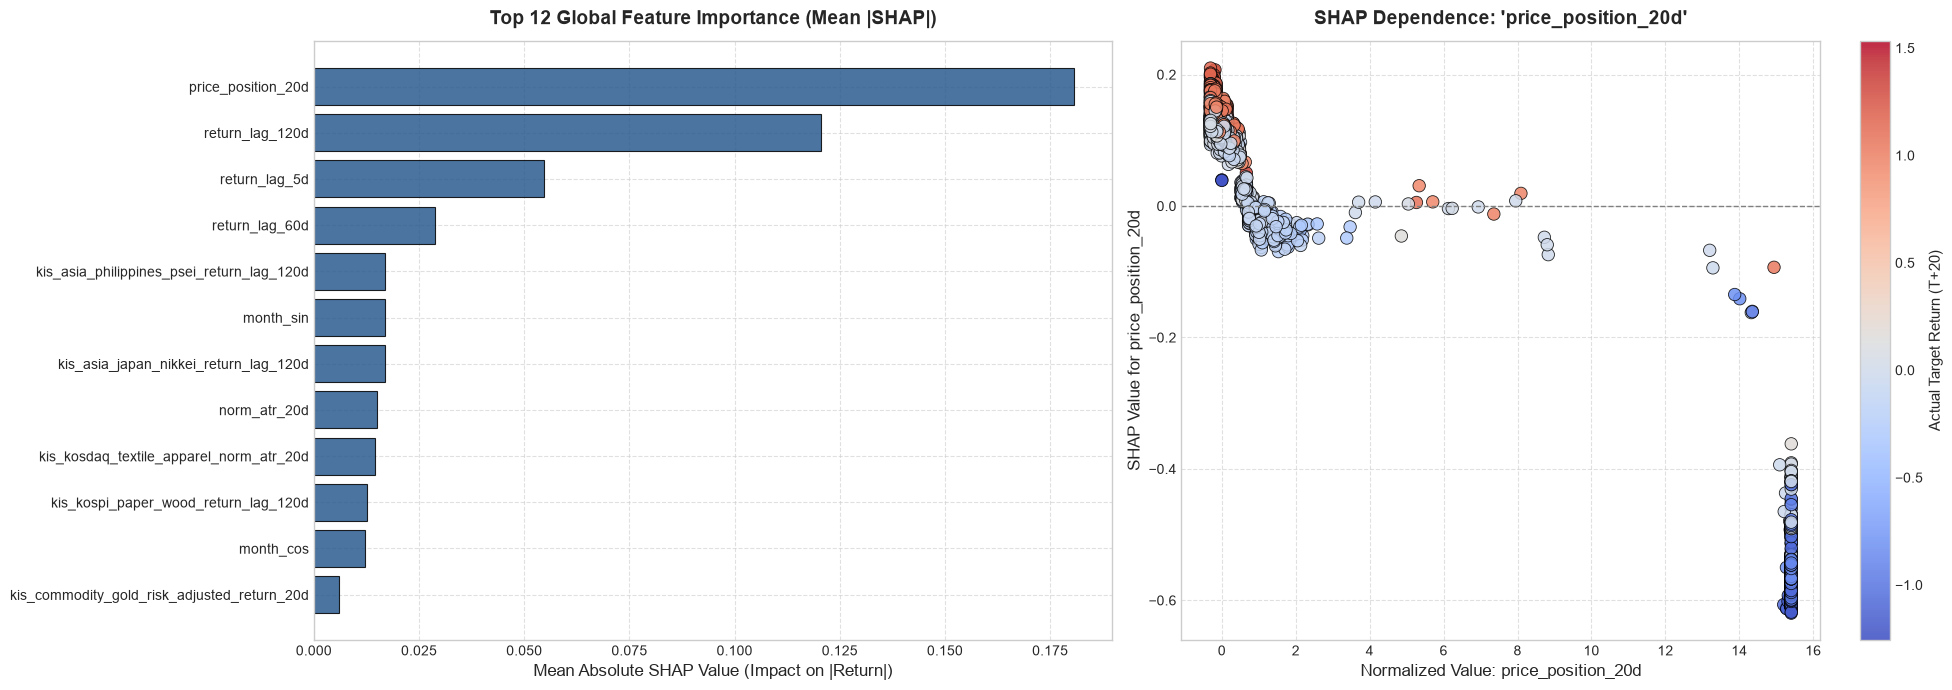

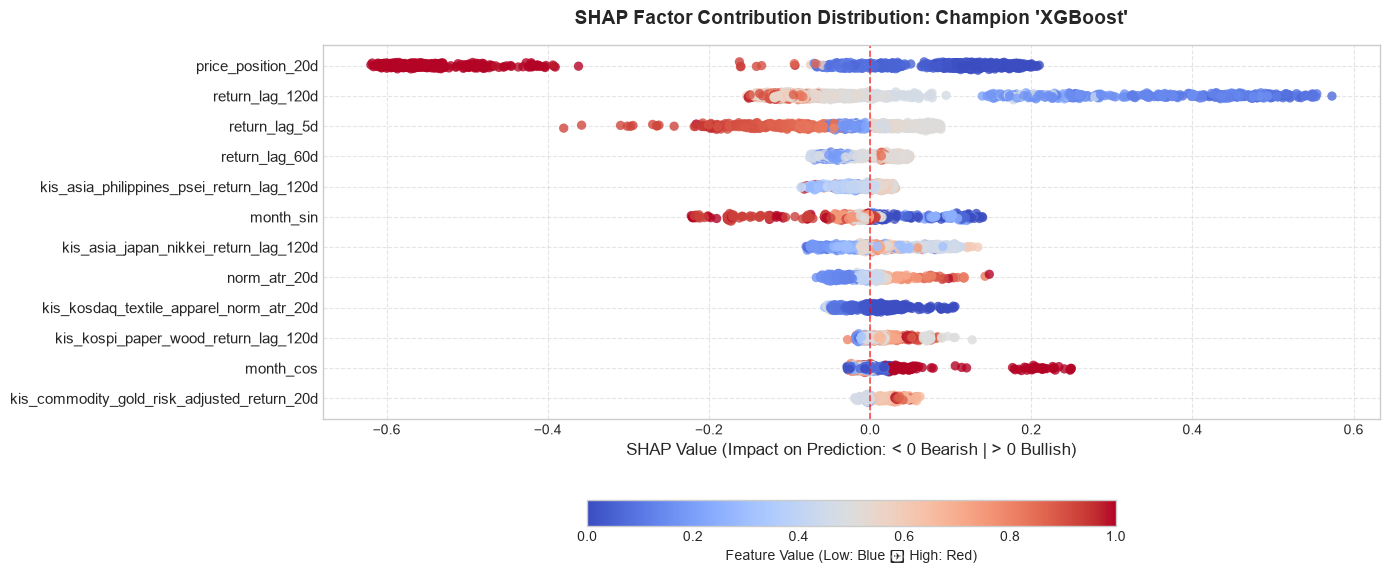


[SHAP Factor Contribution Ranking Dashboard] Top Driver Factor: 'price_position_20d'


,피처 명칭 (Feature Name),평균 절대 SHAP (Mean |SHAP|),기여도 비중 (Importance %),주요 기여 방향성 (Market Bias)
Rank,,,,
1,price_position_20d,0.180758,36.44%,하락 압력 (Bearish)
2,return_lag_120d,0.120510,24.30%,하락 압력 (Bearish)
3,return_lag_5d,0.054817,11.05%,하락 압력 (Bearish)
4,return_lag_60d,0.028875,5.82%,상승 견인 (Bullish)
5,kis_asia_philippines_psei_return_lag_120d,0.016971,3.42%,상승 견인 (Bullish)
6,month_sin,0.016927,3.41%,하락 압력 (Bearish)
7,kis_asia_japan_nikkei_return_lag_120d,0.016831,3.39%,상승 견인 (Bullish)
8,norm_atr_20d,0.014997,3.02%,상승 견인 (Bullish)
9,kis_kosdaq_textile_apparel_norm_atr_20d,0.014599,2.94%,하락 압력 (Bearish)


In [8]:
# ==============================================================================
# [셀 4] SHAP 기반 XAI 거시 금융 팩터 해석 (Explainable AI)
# ==============================================================================
import matplotlib.pyplot as plt
from src.model.evaluation.shap_explainer import ShapExplainer
from src.model.visualization.shap_visualizer import ShapVisualizer

print("=" * 122)
print(f"[Explainable AI (SHAP) Analysis Launch] Target Champion Model: '{champion_model_name}'")
print(f"Target Feature Matrix Shape: {X_train.shape} (Full Train Partition)")
print("=" * 122)

# ------------------------------------------------------------------------------
# Step 1 & 2. SHAP 값 다형성 산출 및 정량적 팩터 기여도 정산 (단 2줄)
# ------------------------------------------------------------------------------
shap_explainer = ShapExplainer()
shap_result = shap_explainer.explain(model=champion_model, X_train=X_train)

# ------------------------------------------------------------------------------
# Step 3. 포트폴리오 맞춤형 SHAP XAI 종합 시각화 리포트 사출 (단 4줄)
# ------------------------------------------------------------------------------
fig_importance = ShapVisualizer.plot_importance_and_dependence(X_train=X_train, y_train=y_train, shap_result=shap_result)
plt.show()

fig_distribution = ShapVisualizer.plot_factor_distribution(X_train=X_train, shap_result=shap_result, champion_model_name=champion_model_name)
plt.show()

# ------------------------------------------------------------------------------
# Step 4. XAI 팩터 기여도 정산 대시보드 표 사출 및 MLflow 일괄 영속화
# ------------------------------------------------------------------------------
print("\n" + "=" * 122)
print(f"[SHAP Factor Contribution Ranking Dashboard] Top Driver Factor: '{shap_result.top_feature_name}'")
print("=" * 122)
display(shap_result.display_dataframe.head(10))

tracker.log_xai_reports(
    champion_model_name=champion_model_name,
    shap_ranking_dataframe=shap_result.ranking_dataframe,
    fig_importance=fig_importance,
    fig_distribution=fig_distribution,
    top_driver_feature=shap_result.top_feature_name
)

In [10]:
# ==============================================================================
# [셀 5] 챔피언 모델 아티팩트(champion_model.pkl) 직렬화 저장 및 배포 검증
# ==============================================================================
from src.model.deployment.single_model_deployer import SingleModelDeployer

print("=" * 122)
print(f"[Champion Model Deployment Pipeline Launch] Target Champion: '{champion_model_name}'")
print("=" * 122)

deployer = SingleModelDeployer()

# ------------------------------------------------------------------------------
# Step 1. 챔피언 모델 아티팩트 직렬화 저장 (Save)
# ------------------------------------------------------------------------------
artifact_path = deployer.save(model=champion_model, artifact_path="champion_single_model.pkl")

# ------------------------------------------------------------------------------
# Step 2. 저장된 아티팩트 복원 무결성 및 추론 레이턴시 검증 (Verify)
# ------------------------------------------------------------------------------
verification_result = deployer.verify(
    champion_dto=champion,
    X_test=X_test,
    y_test=y_test,
    artifact_path=artifact_path
)

# ------------------------------------------------------------------------------
# Step 3. 최종 모델 배포 사출서 생성 및 대시보드 출력 (Summarize)
# ------------------------------------------------------------------------------
deployment_summary_dataframe = deployer.summarize(
    champion_dto=champion,
    verification_result=verification_result
)

print("\n" + "=" * 122)
print("[AssetMind Champion Model Final Deployment Specification]")
print("=" * 122)
display(deployment_summary_dataframe)

# ------------------------------------------------------------------------------
# Step 4. MLflow Model Registry 정식 승격 및 아티팩트 영속화
# ------------------------------------------------------------------------------
tracker.register_champion_model(
    champion_model_name=champion_model_name,
    artifact_path=artifact_path,
    deployment_summary_dataframe=deployment_summary_dataframe,
    single_sample_latency_ms=verification_result.single_sample_latency_ms
)

[Champion Model Deployment Pipeline Launch] Target Champion: 'XGBoost'
💾 [Artifact Saved] 'champion_single_model.pkl' (크기: 453.70 KB)

[AssetMind Champion Model Final Deployment Specification]


,세부 내용 (Value)
항목 (Field),
챔피언 모델 알고리즘 (Algorithm),XGBoost
모델 아티팩트 경로 (Artifact Path),champion_single_model.pkl
아티팩트 파일 크기 (File Size),453.70 KB
최종 투입 피처 수 (Feature Dimension),12 Features
최적 하이퍼파라미터 (Best Parameters),"objective=reg:absoluteerror, n_estimators=390, max_depth=3, learning_rate=0.0138, min_child_weight=3, gamma=0.3281, subsample=0.7170, colsample_bytree=0.9369, reg_alpha=0.2931, reg_lambda=0.0054, random_state=42"
Walk-Forward CV 평균 적중률 (CV MDA),69.15%
Walk-Forward CV 평균 제곱근 오차 (CV RMSE),0.291584
[L1] 테스트 방향성 적중률 (Test MDA),65.71%
[L1] 테스트 평균 제곱근 오차 (Test RMSE),0.258719


🎯 [MLflow Model Registry] 'Champion_AssetMind_Regressor' (Version: 15) 정식 승격 완료
